<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/15_Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# R15 · Decision Trees — Taj Hotels Booking Cancellations
**The problem:** 37 % of Taj bookings get cancelled. Empty rooms earn nothing, so the revenue team wants to know **which bookings will cancel**, as rules a front-desk manager can read.



## 0. The Data

In [ ]:
!gdown 1BNSKS0Lg5S4-YWz3_TKXxq6ngC_p98U9
!gdown 1yGyOy2-QueXEspQgPkPwcuH7v1lUJ7Fn

Downloading...
From: https://drive.google.com/uc?id=1BNSKS0Lg5S4-YWz3_TKXxq6ngC_p98U9
To: /content/hotel_bookings_5k.csv
100% 344k/344k [00:00<00:00, 75.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yGyOy2-QueXEspQgPkPwcuH7v1lUJ7Fn
To: /content/hotel_bookings.csv
100% 16.9M/16.9M [00:00<00:00, 221MB/s]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

bookings = pd.read_csv("hotel_bookings_5k.csv")
print(bookings.shape)
bookings.head()

(5000, 14)


,hotel,lead_time,deposit_type,previous_cancellations,booking_changes,total_of_special_requests,required_car_parking_spaces,market_segment,customer_type,adr,adults,stays_in_week_nights,is_repeated_guest,is_canceled
0,Resort Hotel,203,No Deposit,0,4,0,0,Direct,Transient,66.8,2,5,0,0
1,City Hotel,82,No Deposit,0,0,0,0,Online TA,Transient,76.5,2,3,0,1
2,City Hotel,25,No Deposit,0,2,1,0,Offline TA/TO,Transient-Party,60.0,3,3,0,0
3,City Hotel,1,No Deposit,0,0,0,0,Online TA,Transient-Party,95.0,1,1,0,0
4,City Hotel,70,No Deposit,0,0,0,0,Online TA,Transient,108.0,2,2,0,0


In [ ]:
print("cancel rate:", round(bookings["is_canceled"].mean(), 3))

cancel rate: 0.381


In [ ]:
bookings["is_canceled"].value_counts(normalize=True)

,proportion
is_canceled,
0,0.6194
1,0.3806


In [ ]:
# "Imbalanced Data"

In [ ]:
data = pd.get_dummies(bookings, drop_first=True, dtype=int)

X = data.drop(columns="is_canceled")
y = data["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("baseline (everyone shows up):", round(1 - y_test.mean(), 3))

baseline (everyone shows up): 0.619


In [ ]:
data.head()

,lead_time,previous_cancellations,booking_changes,total_of_special_requests,required_car_parking_spaces,adr,adults,stays_in_week_nights,is_repeated_guest,is_canceled,...,deposit_type_Refundable,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,203,0,4,0,0,66.8,2,5,0,0,...,0,0,0,1,0,0,0,0,1,0
1,82,0,0,0,0,76.5,2,3,0,1,...,0,0,0,0,0,0,1,0,1,0
2,25,0,2,1,0,60.0,3,3,0,0,...,0,0,0,0,0,1,0,0,0,1
3,1,0,0,0,0,95.0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1
4,70,0,0,0,0,108.0,2,2,0,0,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
X_train.shape

(4000, 21)

In [ ]:
def score(model):
    model.fit(X_train, y_train)

    print("train:", round(model.score(X_train, y_train), 3),
          "| test:", round(model.score(X_test, y_test), 3))
    return model

In [ ]:
bookings['deposit_type'].value_counts()

,count
deposit_type,
No Deposit,4346
Non Refund,645
Refundable,9


## 1. A Tree Is a Set of Questions

In [ ]:
bookings.groupby("deposit_type")["is_canceled"].mean()

,is_canceled
deposit_type,
No Deposit,0.289922
Non Refund,0.995349
Refundable,0.111111


train: 0.774 | test: 0.739


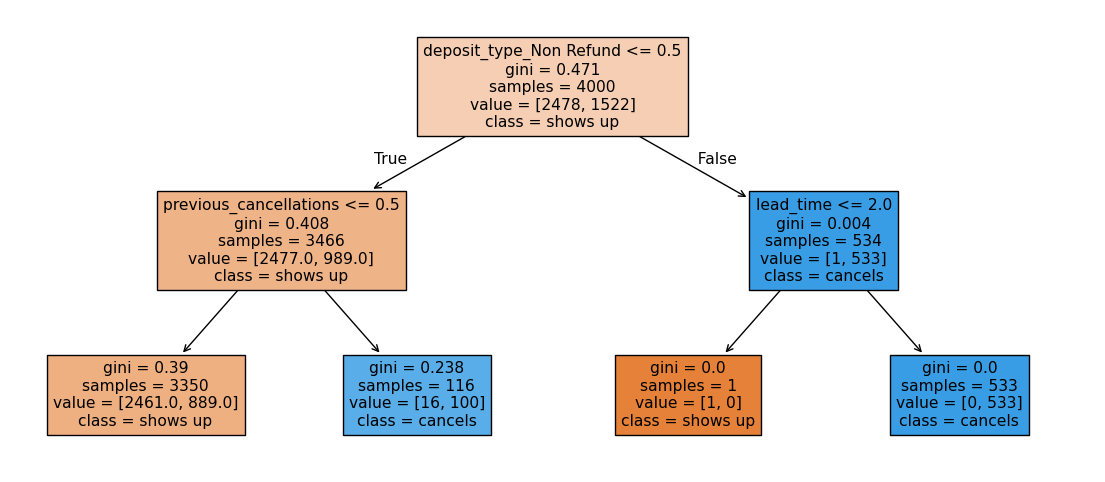

In [ ]:
model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2 = score(model)

plt.figure(figsize=(14, 6))
plot_tree(tree2, feature_names=X.columns, class_names=["shows up", "cancels"], filled=True)
plt.show()

In [ ]:
# Test: change max_depth to 3. Which new questions appear? Does test accuracy move?

In [ ]:
# gini/entropy : randomness, uncertaininty , measure of impurity
# information gain.

In [ ]:
# entropy/gini = 0
# entropy/gini = 0.12
# entropy/gini = 1/0.5
# entropy/gini =


# 1 - SUM(p^2 + p^2)

In [ ]:
1 - (0.38**2 + 0.62**2)

0.47119999999999995

In [ ]:
1 - (1.0**2 + 0.0**2)

0.0

## 2. How the Tree Picks a Question: Gini

In [ ]:
def gini(outcomes):
    p = outcomes.mean()
    return 1 - (p**2 + (1-p)**2)

print("root node Gini:", round(gini(y_train), 3))

root node Gini: 0.471


In [ ]:
def split_gini(column):
    left = y_train[X_train[column] > 0]
    right = y_train[X_train[column] == 0]

    return (len(left) * gini(left) + len(right) * gini(right)) / len(y_train)

print("non-refundable deposit:", split_gini("deposit_type_Non Refund"))
print("cancelled before:      ", split_gini("previous_cancellations"))
print("resort vs city hotel:  ", split_gini("hotel_Resort Hotel"))
print("market seg direct:  ", split_gini("market_segment_Direct"))
print("market seg Corporate:  ", split_gini("market_segment_Corporate"))
print("is_repeated_guest:  ", split_gini("is_repeated_guest"))

non-refundable deposit: 0.3538967843859341
cancelled before:       0.4313611728579581
resort vs city hotel:   0.4607380794335657
market seg direct:   0.45787404617193767
market seg Corporate:   0.4698069142061835
is_repeated_guest:   0.469624097093004


In [ ]:
X_train.head()

,lead_time,previous_cancellations,booking_changes,total_of_special_requests,required_car_parking_spaces,adr,adults,stays_in_week_nights,is_repeated_guest,hotel_Resort Hotel,...,deposit_type_Refundable,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
888,6,0,0,3,0,159.0,2,1,0,0,...,0,0,0,0,0,0,1,0,1,0
2637,0,0,0,1,0,95.0,2,1,0,1,...,0,0,0,0,0,0,1,0,1,0
4544,31,0,0,3,0,157.5,2,1,0,0,...,0,0,0,0,0,0,1,0,1,0
569,0,0,0,0,0,170.0,2,1,1,0,...,0,0,0,1,0,0,0,0,1,0
1590,11,0,0,1,0,151.0,2,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
1 - ((4/9)**2 + (5/9)**2)

0.49382716049382713

## 3. The Overfitting

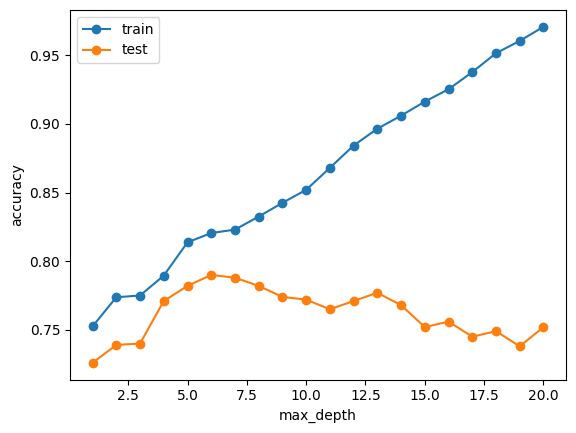

In [ ]:
train_scores, test_scores = [], []
depths = range(1, 21)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="o", label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [ ]:
deep_tree = score(DecisionTreeClassifier(max_depth=6, random_state=42))
print("depth:", deep_tree.get_depth(), "| leaves:", deep_tree.get_n_leaves())

train: 0.821 | test: 0.79
depth: 6 | leaves: 27


## 4. Why It Overfits

In [ ]:
leaf_sizes = pd.Series(deep_tree.apply(X_train)).value_counts()     # bookings in each leaf
print("leaves holding a single booking:", (leaf_sizes == 1).sum(), "of", len(leaf_sizes))

leaves holding a single booking: 2 of 27


In [ ]:
best_tree = score(DecisionTreeClassifier(max_depth=6, random_state=42))
score(DecisionTreeClassifier(min_samples_leaf=10, random_state=42));

train: 0.821 | test: 0.79
train: 0.853 | test: 0.785


In [ ]:
# Test: try min_samples_leaf = 1, 5, 20, 50, 100. Where is test accuracy best?

## 5. Feature importances

In [ ]:
importance = pd.Series(best_tree.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
deposit_type_Non Refund,0.564468
lead_time,0.117321
total_of_special_requests,0.101514
previous_cancellations,0.095850
market_segment_Online TA,0.074044
required_car_parking_spaces,0.025881
booking_changes,0.008624
adr,0.003412
is_repeated_guest,0.002139
stays_in_week_nights,0.001801


## 6. Full Data ( 119,390 Bookings )

In [ ]:
all_bookings = pd.read_csv("hotel_bookings.csv")[bookings.columns]     # same 14 columns

data = pd.get_dummies(all_bookings, drop_first=True, dtype=int)
X = data.drop(columns="is_canceled")
y = data["is_canceled"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for depth in [6, 15, None]:
    print("max_depth", depth, end=" : ")
    score(DecisionTreeClassifier(max_depth=depth, random_state=42))

max_depth 6 : train: 0.808 | test: 0.808
max_depth 15 : train: 0.846 | test: 0.824
max_depth None : train: 0.986 | test: 0.809


In [ ]:
# https://mlu-explain.github.io/decision-tree/

# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [ ]:
# gini = 0.5
# entropy = 1

# Interveiw prep
1. How does a decision tree choose a split?
2. Gini vs entropy?
3. Why do decision trees overfit so easily?
4. How do you stop a tree overfitting?
5. Do trees need feature scaling?
6. How does a tree produce a probability?
7. What is feature importance in a tree, and its limits?
8. Why is tree building called greedy?
9. Can decision trees do regression?
10. Pros and cons of a single decision tree?
11. What is high variance, in tree terms?
12. A tree scores 100 % on train and 70 % on test. What do you do?